# Dataset Analysis — Task03_Liver (MSD)

Analiza surowych danych NIfTI z Medical Segmentation Decathlon:
- liczba wolumenów
- adnotacje guzów (label=2)
- rozkład liczby guzów per pacjent
- rozdzielczości i grubości warstw
- objętości wątroby i guzów

In [23]:
import os
import json
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
from scipy import ndimage
from tqdm import tqdm

plt.rcParams['figure.dpi'] = 120

In [24]:
# Ścieżki — auto-detekcja katalogu projektu
from pathlib import Path
import os

_cwd = Path(os.getcwd())
_candidates = [
    _cwd / 'data' / 'Task03_Liver' / 'Task03_Liver',       # cwd = project root
    _cwd / '../data' / 'Task03_Liver' / 'Task03_Liver',     # cwd = notebooks/
    _cwd / '../../data' / 'Task03_Liver' / 'Task03_Liver',  # cwd = notebooks/subdir
]

ROOT = next((c.resolve() for c in _candidates if c.resolve().exists()), None)

if ROOT is None:
    raise FileNotFoundError(
        f"Nie znaleziono Task03_Liver/Task03_Liver.\ncwd={_cwd}\n"
        "Upewnij się, że dane są w data/Task03_Liver/Task03_Liver/"
    )

IMAGES_DIR = ROOT / 'imagesTr'
LABELS_DIR = ROOT / 'labelsTr'
DATASET_JSON = ROOT / 'dataset.json'

print(f'ROOT:             {ROOT}')
print(f'imagesTr exists:  {IMAGES_DIR.exists()}')
print(f'labelsTr exists:  {LABELS_DIR.exists()}')
print(f'dataset.json:     {DATASET_JSON.exists()}')

if DATASET_JSON.exists():
    with open(DATASET_JSON) as f:
        meta = json.load(f)
    print(f"\nNazwa:    {meta.get('name')}")
    print(f"Opis:     {meta.get('description')}")
    print(f"Etykiety: {meta.get('labels')}")

ROOT:             /home/pswiebocki/projects/LiverTumorSegmentation/data/Task03_Liver/Task03_Liver
imagesTr exists:  True
labelsTr exists:  True
dataset.json:     True

Nazwa:    Liver
Opis:     Liver, and cancer segmentation
Etykiety: {'0': 'background', '1': 'liver', '2': 'cancer'}


In [25]:
# Dopasuj pary obraz–maska po nazwie pliku (pomijaj ukryte pliki macOS ._*)
image_files = sorted(f for f in IMAGES_DIR.glob('*.nii.gz') if not f.name.startswith('._')) if IMAGES_DIR.exists() else []
label_files = sorted(f for f in LABELS_DIR.glob('*.nii.gz') if not f.name.startswith('._')) if LABELS_DIR.exists() else []

image_ids = {f.name.replace('.nii.gz', ''): f for f in image_files}
label_ids = {f.name.replace('.nii.gz', ''): f for f in label_files}

all_ids = sorted(set(image_ids) | set(label_ids))

print(f'Wolumeny obrazów: {len(image_ids)}')
print(f'Wolumeny masek:   {len(label_ids)}')
print(f'Razem unikalnych ID: {len(all_ids)}')

paired = [(pid, image_ids.get(pid), label_ids.get(pid)) for pid in all_ids]
print(f'\nW pełni sparowanych (obraz+maska): {sum(1 for _,i,l in paired if i and l)}')
print(f'Tylko obraz (brak maski):          {sum(1 for _,i,l in paired if i and not l)}')
print(f'Tylko maska (brak obrazu):         {sum(1 for _,i,l in paired if not i and l)}')

Wolumeny obrazów: 131
Wolumeny masek:   131
Razem unikalnych ID: 131

W pełni sparowanych (obraz+maska): 131
Tylko obraz (brak maski):          0
Tylko maska (brak obrazu):         0


In [26]:
def count_tumor_components(label_arr):
    """Zlicza spójne składowe guza (label=2)."""
    tumor_mask = (label_arr == 2).astype(np.uint8)
    _, n = ndimage.label(tumor_mask)
    return n

def voxel_volume_ml(spacing):
    """Objętość jednego voksela w ml (mm³ → ml)."""
    return float(np.prod(spacing)) / 1000.0

records = []

for pid, img_path, lbl_path in tqdm(paired, desc='Analiza wolumenów'):
    # Pomiń ukryte pliki macOS
    if pid.startswith('._'):
        continue

    record = {'id': pid, 'has_image': img_path is not None, 'has_label': lbl_path is not None}

    if img_path:
        nii_img = nib.load(str(img_path))
        spacing = nii_img.header.get_zooms()
        shape = nii_img.shape
        record.update({
            'spacing_x': float(spacing[0]),
            'spacing_y': float(spacing[1]),
            'spacing_z': float(spacing[2]),
            'dim_x': int(shape[0]),
            'dim_y': int(shape[1]),
            'dim_z': int(shape[2]),
        })

    if lbl_path:
        nii_lbl = nib.load(str(lbl_path))
        lbl_arr = np.asarray(nii_lbl.dataobj)
        lbl_spacing = nii_lbl.header.get_zooms()
        vox_ml = voxel_volume_ml(lbl_spacing)

        liver_voxels = int((lbl_arr == 1).sum())
        tumor_voxels = int((lbl_arr == 2).sum())
        n_tumors = count_tumor_components(lbl_arr)

        record.update({
            'liver_vol_ml': liver_voxels * vox_ml,
            'tumor_vol_ml': tumor_voxels * vox_ml,
            'has_tumor': tumor_voxels > 0,
            'n_tumor_components': n_tumors,
        })

    records.append(record)

df = pd.DataFrame(records)
print(df.shape)
df.head()

Analiza wolumenów: 100%|██████████████████████████████████████████████████████████████| 131/131 [10:43<00:00,  4.91s/it]

(131, 13)


,id,has_image,has_label,spacing_x,spacing_y,spacing_z,dim_x,dim_y,dim_z,liver_vol_ml,tumor_vol_ml,has_tumor,n_tumor_components
0,liver_0,True,True,0.703125,0.703125,5.0,512,512,75,1359.647095,6.404755,True,11
1,liver_1,True,True,0.675781,0.675781,5.0,512,512,123,1470.004853,16.426778,True,12
2,liver_10,True,True,0.769531,0.769531,1.0,512,512,501,1692.070268,14.395856,True,6
3,liver_100,True,True,0.699219,0.699219,0.7,512,512,685,1712.225104,537.202233,True,11
4,liver_101,True,True,0.705078,0.705078,0.7,512,512,683,2255.558640,131.694727,True,20


## 1. Podsumowanie zbioru

In [27]:
total = len(df)
with_label = int(df['has_label'].sum())
with_tumor  = int(df['has_tumor'].sum()) if 'has_tumor' in df.columns else None
without_tumor = with_label - with_tumor if with_tumor is not None else None

print('=== PODSUMOWANIE ZBIORU ===')
print(f'Łączna liczba wolumenów:          {total}')
print(f'Z maską segmentacji:              {with_label}')
if with_tumor is not None:
    print(f'Z adnotacją guza (label=2):       {with_tumor}')
    print(f'Tylko wątroba, brak guza:         {without_tumor}')

if 'n_tumor_components' in df.columns:
    lbl_df = df[df['has_label']].copy()
    print(f'\nŚrednia liczba spójnych guzów/pacjent: {lbl_df["n_tumor_components"].mean():.2f}')
    print(f'Max. liczba guzów u pacjenta:          {int(lbl_df["n_tumor_components"].max())}')

=== PODSUMOWANIE ZBIORU ===
Łączna liczba wolumenów:          131
Z maską segmentacji:              131
Z adnotacją guza (label=2):       118
Tylko wątroba, brak guza:         13

Średnia liczba spójnych guzów/pacjent: 7.92
Max. liczba guzów u pacjenta:          79


## 2. Rozkład liczby guzów per pacjent

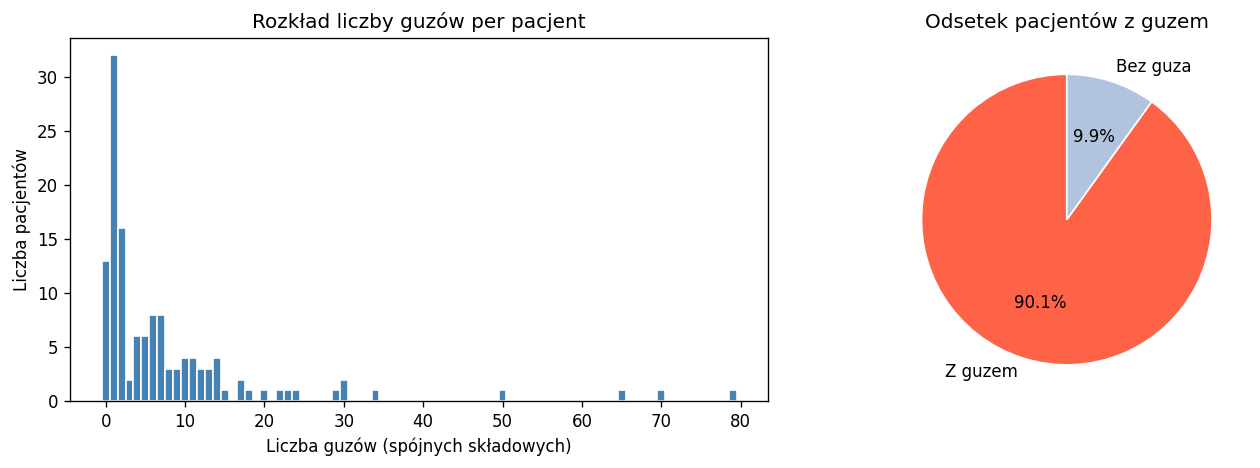

         pacjenci
n_guzów          
0              13
1              32
2              16
3               2
4               6
5               6
6               8
7               8
8               3
9               3
10              4
11              4
12              3
13              3
14              4
15              1
17              2
18              1
20              1
22              1
23              1
24              1
29              1
30              2
34              1
50              1
65              1
70              1
79              1


In [28]:
if 'n_tumor_components' in df.columns:
    lbl_df = df[df['has_label']].copy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    max_tumors = int(lbl_df['n_tumor_components'].max())
    bins = range(0, max_tumors + 2)
    axes[0].hist(lbl_df['n_tumor_components'], bins=bins, align='left',
                 edgecolor='white', color='steelblue')
    axes[0].set_xlabel('Liczba guzów (spójnych składowych)')
    axes[0].set_ylabel('Liczba pacjentów')
    axes[0].set_title('Rozkład liczby guzów per pacjent')
    axes[0].xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    sizes = [int(lbl_df['has_tumor'].sum()), int((~lbl_df['has_tumor']).sum())]
    axes[1].pie(sizes, labels=['Z guzem', 'Bez guza'],
                autopct='%1.1f%%', colors=['tomato', 'lightsteelblue'],
                startangle=90, wedgeprops={'edgecolor': 'white'})
    axes[1].set_title('Odsetek pacjentów z guzem')

    plt.tight_layout()
    plt.show()

    print(lbl_df['n_tumor_components'].value_counts().sort_index()
          .rename('pacjenci').rename_axis('n_guzów').to_frame())
else:
    print('Brak danych masek — dodaj labelsTr.')

## 3. Rozdzielczości i grubości warstw

Exception ignored in: <function tqdm.__del__ at 0x7172aebb36d0>
Traceback (most recent call last):
  File "/home/pswiebocki/miniconda3/envs/liverseg/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/pswiebocki/miniconda3/envs/liverseg/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'


=== ROZDZIELCZOŚCI (mm) ===
Spacing X                : min=0.557  median=0.768  mean=0.793  max=1.000
Spacing Y                : min=0.557  median=0.768  mean=0.793  max=1.000
Grubość warstwy Z        : min=0.700  median=1.000  mean=1.506  max=5.000

=== WYMIARY (voksele) ===
Dim X                    : min=512  median=512  max=512
Dim Y                    : min=512  median=512  max=512
Dim Z (liczba warstw)    : min=74  median=432  max=987


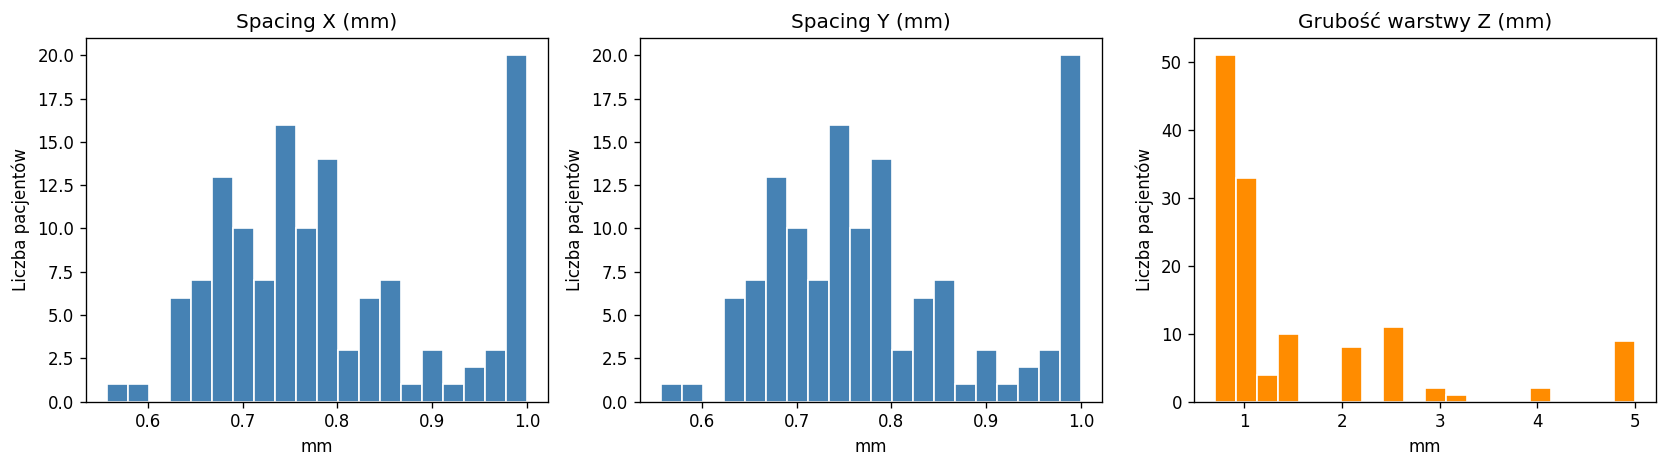

In [29]:
if 'spacing_x' in df.columns:
    img_df = df[df['has_image']].copy()

    print('=== ROZDZIELCZOŚCI (mm) ===')
    for col, name in [('spacing_x', 'Spacing X'), ('spacing_y', 'Spacing Y'), ('spacing_z', 'Grubość warstwy Z')]:
        s = img_df[col]
        print(f'{name:25s}: min={s.min():.3f}  median={s.median():.3f}  mean={s.mean():.3f}  max={s.max():.3f}')

    print('\n=== WYMIARY (voksele) ===')
    for col, name in [('dim_x', 'Dim X'), ('dim_y', 'Dim Y'), ('dim_z', 'Dim Z (liczba warstw)')]:
        s = img_df[col]
        print(f'{name:25s}: min={int(s.min())}  median={int(s.median())}  max={int(s.max())}')

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, col, title, color in zip(
        axes,
        ['spacing_x', 'spacing_y', 'spacing_z'],
        ['Spacing X (mm)', 'Spacing Y (mm)', 'Grubość warstwy Z (mm)'],
        ['steelblue', 'steelblue', 'darkorange']
    ):
        ax.hist(img_df[col], bins=20, edgecolor='white', color=color)
        ax.set_xlabel('mm')
        ax.set_ylabel('Liczba pacjentów')
        ax.set_title(title)

    plt.tight_layout()
    plt.show()
else:
    print('Brak danych obrazów.')

## 4. Objętości wątroby i guzów

=== OBJĘTOŚCI WĄTROBY (ml) ===
count     131.0
mean     1647.0
std       415.8
min       541.8
25%      1379.7
50%      1592.3
75%      1850.0
max      3194.8

=== OBJĘTOŚCI GUZA (ml) — tylko przypadki z guzem ===
count    118.0
mean      86.6
std      158.2
min        0.0
25%        3.5
50%       16.6
75%      108.3
max      987.7

Średni udział guza w wątrobie: 5.11%
Mediana udziału guza:          0.96%


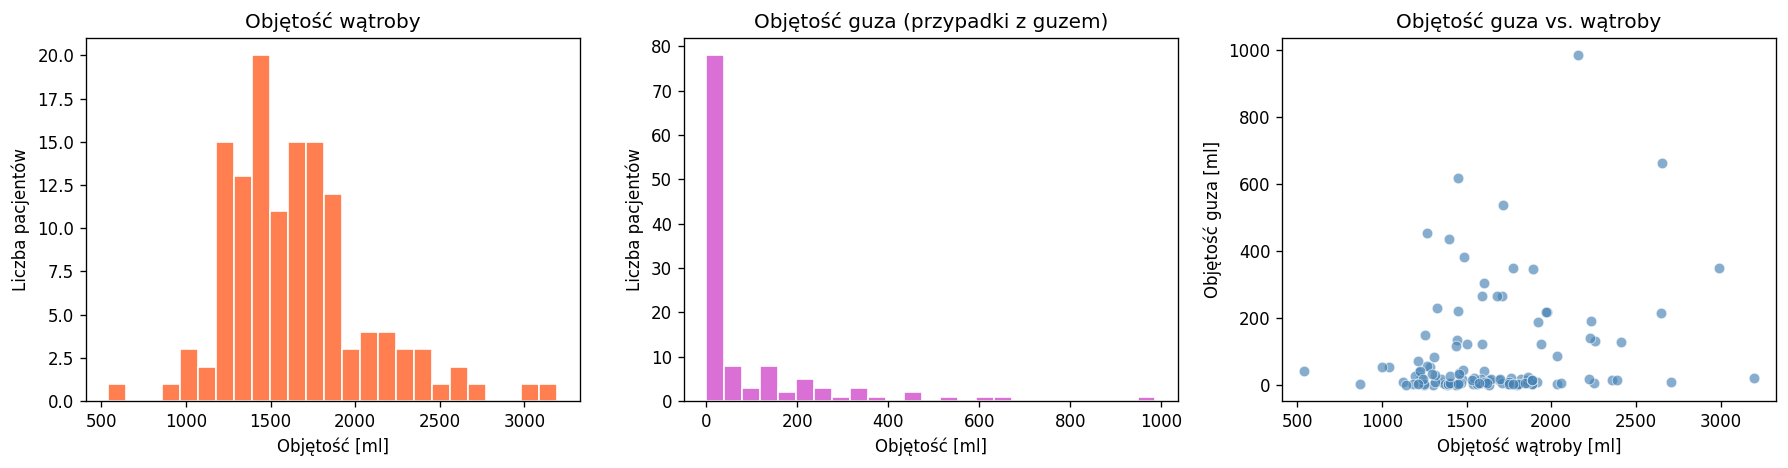

In [30]:
if 'liver_vol_ml' in df.columns:
    lbl_df = df[df['has_label']].copy()
    tumor_df = lbl_df[lbl_df['has_tumor']].copy()

    print('=== OBJĘTOŚCI WĄTROBY (ml) ===')
    print(lbl_df['liver_vol_ml'].describe().round(1).to_string())

    print('\n=== OBJĘTOŚCI GUZA (ml) — tylko przypadki z guzem ===')
    if len(tumor_df):
        print(tumor_df['tumor_vol_ml'].describe().round(1).to_string())
        tumor_df['tumor_fraction_%'] = 100 * tumor_df['tumor_vol_ml'] / tumor_df['liver_vol_ml']
        print(f'\nŚredni udział guza w wątrobie: {tumor_df["tumor_fraction_%"].mean():.2f}%')
        print(f'Mediana udziału guza:          {tumor_df["tumor_fraction_%"].median():.2f}%')
    else:
        print('Brak przypadków z guzem.')

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].hist(lbl_df['liver_vol_ml'], bins=25, edgecolor='white', color='coral')
    axes[0].set_xlabel('Objętość [ml]')
    axes[0].set_ylabel('Liczba pacjentów')
    axes[0].set_title('Objętość wątroby')

    if len(tumor_df):
        axes[1].hist(tumor_df['tumor_vol_ml'], bins=25, edgecolor='white', color='orchid')
        axes[1].set_xlabel('Objętość [ml]')
        axes[1].set_ylabel('Liczba pacjentów')
        axes[1].set_title('Objętość guza (przypadki z guzem)')

        axes[2].scatter(tumor_df['liver_vol_ml'], tumor_df['tumor_vol_ml'],
                        alpha=0.65, edgecolors='white', linewidths=0.5, color='steelblue', s=40)
        axes[2].set_xlabel('Objętość wątroby [ml]')
        axes[2].set_ylabel('Objętość guza [ml]')
        axes[2].set_title('Objętość guza vs. wątroby')

    plt.tight_layout()
    plt.show()
else:
    print('Brak danych masek — dodaj labelsTr.')

## 5. Tabela zbiorcza

In [31]:
display_cols = [c for c in [
    'id', 'spacing_x', 'spacing_y', 'spacing_z',
    'dim_x', 'dim_y', 'dim_z',
    'liver_vol_ml', 'tumor_vol_ml',
    'n_tumor_components', 'has_tumor'
] if c in df.columns]

df[display_cols].sort_values('id').reset_index(drop=True)

,id,spacing_x,spacing_y,spacing_z,dim_x,dim_y,dim_z,liver_vol_ml,tumor_vol_ml,n_tumor_components,has_tumor
0,liver_0,0.703125,0.703125,5.000000,512,512,75,1359.647095,6.404755,11,True
1,liver_1,0.675781,0.675781,5.000000,512,512,123,1470.004853,16.426778,12,True
2,liver_10,0.769531,0.769531,1.000000,512,512,501,1692.070268,14.395856,6,True
3,liver_100,0.699219,0.699219,0.700000,512,512,685,1712.225104,537.202233,11,True
4,liver_101,0.705078,0.705078,0.700000,512,512,683,2255.558640,131.694727,20,True
...,...,...,...,...,...,...,...,...,...,...,...
126,liver_95,0.738000,0.738000,0.800000,512,512,841,1772.540285,1.124581,6,True
127,liver_96,0.746094,0.746094,0.700000,512,512,722,2225.170101,15.794055,29,True
128,liver_97,0.722656,0.722656,0.700000,512,512,671,1677.245571,265.146114,13,True
129,liver_98,0.734375,0.734375,0.700000,512,512,645,1326.914850,229.770127,17,True
